<a href="https://colab.research.google.com/github/VikaBilyk/numeric_methods/blob/main/numeric_method_relaxation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Введіть ліву межу проміжку a: 0.1
Введіть праву межу проміжку b: 0.5
Введіть початкове значення x0: 0.315
Введіть точність epsilon: 0.0001
Оптимальне значення tau: 0.36720278189961625
Очікувана кількість ітерацій: 5
Наближене значення кореня: 0.31597528208949666
Реальна кількість ітерацій: 5

Індекс     Значення x           f(x)                 Точність            
0          0.3163773977         0.0028217611         0.0013773977        
1          0.3153412392         -0.0021223558        0.0010361585        
2          0.3161205742         0.0015965009         0.0007793350        
3          0.3155343346         -0.0012008283        0.0005862396        
4          0.3159752821         0.0009032803         0.0004409475        




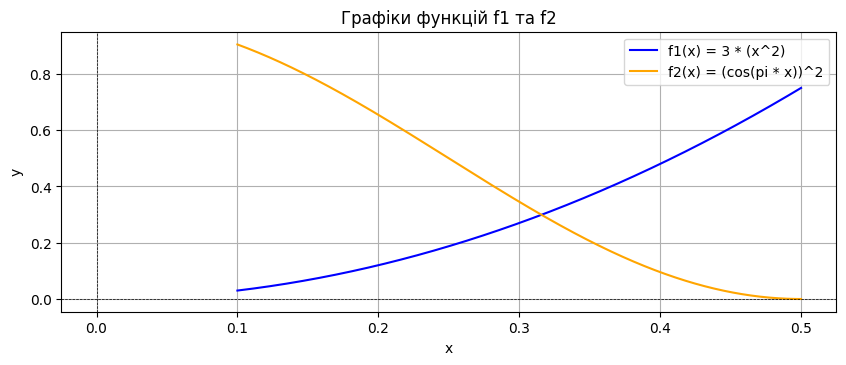

In [33]:
import math
import numpy as np
import matplotlib.pyplot as plt

# Функція для рівняння f(x)
def f(x):
    return 3 * (x ** 2) - (math.cos(math.pi * x) ** 2)

# Похідна функції для f(x)
def df(x):
    return 6 * x + math.pi * math.sin(2 * math.pi * x)

# Метод релаксації
def relaxation_method(x0, tau, epsilon, q, max_iterations):
    x_n = x0
    iterations = []
    for i in range(max_iterations):
        x_next = x_n - tau * f(x_n)
        accuracy = abs(x_next - x_n)
        iterations.append((i, x_next, f(x_next), accuracy))  # Додаємо інформацію про ітерацію
        if accuracy < epsilon:  # умова зупинки за точністю
            return x_next, i, iterations
        x_n = x_next
    return x_n, max_iterations, iterations

# Обчислення необхідної кількості ітерацій
def calculate_iterations(z0, epsilon, q):
    if q == 1:
        raise ValueError("Значення q не повинно бути рівним 1, це призводить до нескінченної кількості ітерацій.")
    primary_calc = math.log(abs(z0 / epsilon)) / math.log(1 / q)
    return math.ceil(primary_calc + 1)

# Виведення таблиці результатів
def print_table_simple_iteration(x_vals):
    print(f"\n{'Індекс':<10} {'Значення x':<20} {'f(x)':<20} {'Точність':<20}")
    print("=" * 70)

    for i, (index, x_val, fx_val, accuracy) in enumerate(x_vals):
        print(f"{index:<10} {x_val:<20.10f} {fx_val:<20.10f} {accuracy:<20.10f}")
    print('\n')

# Основна програма
if __name__ == "__main__":
    # Введення початкових даних
    a = float(input("Введіть ліву межу проміжку a: "))
    b = float(input("Введіть праву межу проміжку b: "))
    x0 = float(input("Введіть початкове значення x0: "))
    epsilon = float(input("Введіть точність epsilon: "))

    # Генерація значень x у заданому проміжку
    x_values = np.linspace(a, b, 1000)
    z0 = np.max(np.abs(x0 - x_values))

    # Розрахунок оптимального значення tau
    m1 = min(df(a), df(b))
    M1 = max(df(a), df(b))

    if M1 + m1 == 0:
        raise ValueError("Неможливо розрахувати оптимальне значення tau через ділення на нуль.")

    tau_opt = 2 / (M1 + m1)

    # Обчислення q
    q = (M1 - m1) / (M1 + m1)

    # Перевірка на випадок q = 1
    if q == 1:
        raise ValueError("Значення q не може дорівнювати 1, оскільки це призведе до нескінченної кількості ітерацій.")

    # Обчислення кількості ітерацій
    n_iterations = calculate_iterations(z0, epsilon, q)

    print(f"Оптимальне значення tau: {tau_opt}")
    print(f"Очікувана кількість ітерацій: {n_iterations}")

    # Використання методу релаксації
    root, actual_iterations, iterations_data = relaxation_method(x0, tau_opt, epsilon, q, n_iterations)

    print(f"Наближене значення кореня: {root}")
    print(f"Реальна кількість ітерацій: {actual_iterations}")

    # Виведення таблиці
    print_table_simple_iteration(iterations_data)

    # Малювання графіків функцій
    f1_values = 3 * (x_values ** 2)
    f2_values = (np.cos(np.pi * x_values) ** 2)

    plt.figure(figsize=(10, 8))

    # Графіки функцій
    plt.subplot(2, 1, 1)
    plt.plot(x_values, f1_values, label='f1(x) = 3 * (x^2)', color='blue')
    plt.plot(x_values, f2_values, label='f2(x) = (cos(pi * x))^2', color='orange')
    plt.title('Графіки функцій f1 та f2')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.axhline(0, color='black', linewidth=0.5, ls='--')
    plt.axvline(0, color='black', linewidth=0.5, ls='--')
    plt.grid()
    plt.legend()
    plt.show()
